# Uncertainty Explainer — Demo Workflow

Este notebook muestra el pipeline completo de la librería:

1. **Datos**: generamos un dataset de clasificación sintético
2. **Modelo**: entrenamos un `RandomForestClasifier`
3. **Predicción conformal**: calibramos intervalos de predicción
4. **Explicación**: Explicamos la incertidumbre (set_size, credibility, confidence) generada por la predicción conformal.
    - ***Valores Shapley***: explicamos qué features contribuyen a la incertidumbre
    - ***Partial Dependence Plot (PDP)***: Explicamos cómo cambia la incertidumbre media del modelo cuando cambia las features seleccionadas (efecto marginal).
    - ***LIME***: Para un punto de interés, se ajusta un modelo interpretable localmente que permita interpretar los parámetros sobre la amplitud del intervalo como variable de respuesta.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from uncertainty_explainer import (
    UncertaintyExplanationPipeline,
    CrepesConformalClassifier,
    ClassificationExplanationResult,
)

import numpy as np
import tqdm
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification


c:\Users\veronica.seguro\Documents\Projects\Uncertainty-Explainer\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Data

We generate a synthetic dataset and wrap it in a `DataFrame` so that feature names propagate automatically to the explanations.

In [3]:
np.random.seed(42)

X, y = make_classification(
    n_samples=5000,      
    n_features=7,       
    n_informative=4,    
    n_redundant=2,      
    n_repeated=0,
    n_classes=4,         
    weights=[0.1, 0.6, 0.2, 0.1],
    flip_y=0.02,         # ruido en etiquetas
    class_sep=1.0,
    random_state=42
)
feature_names = [f"feat_{i}" for i in range(X.shape[1])]
X = pd.DataFrame(X, columns=feature_names)

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_calib, X_test, y_calib, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Train: {X_train.shape[0]}, Calibration: {X_calib.shape[0]}, Test: {X_test.shape[0]}")
print(f"Y distribution \n{pd.Series(y).value_counts()}")
X_train.head()

Train: 3000, Calibration: 1000, Test: 1000
Y distribution 
1    2965
2    1004
3     517
0     514
Name: count, dtype: int64


,feat_0,feat_1,feat_2,feat_3,feat_4,feat_5,feat_6
4576,-0.977078,0.582937,0.586420,-2.447943,-0.230677,-1.803359,-1.303755
1088,-1.567535,-2.435604,3.550975,0.350057,-3.173868,2.247694,1.215141
479,-0.828901,1.596840,0.787136,-0.315817,-1.378725,-0.712821,-1.562589
727,-0.071509,0.295022,0.929094,-1.370659,0.255629,0.560679,0.612000
3783,-0.799884,1.396124,0.399738,-3.329615,0.804247,-1.627552,-0.917032


## 2. Quickstart (3 lines): most basic case for a user

The minimal API only requires a model. `conformal_method`, `confidence`, `xai_method`, and the calibration split all use sensible defaults. The `ExplanationResult` already carries the intervals (`lower`, `upper`, `interval_width`) — there is no need to call `predict()` separately.

In [4]:
quick = UncertaintyExplanationPipeline(model=RandomForestClassifier(n_estimators=20, random_state=0))
quick.fit(X_train, y_train)
result = quick.explain(X_test, show_plots=False)

ExactExplainer explainer: 1001it [22:36,  1.36s/it]                             


In [ ]:
covered = result.prediction_set[np.arange(len(y_test)), y_test]
coverage = covered.mean()
print(f"Coverage: {coverage:.3f}")
print(f"Mean set size: {result.set_size.mean():.2f}")

Coverage: 0.920
Mean interval width: 1.34


## 3. Crear el pipeline

El pipeline recibe un classificador o regressor sklearn, un método conformal y un método xai.

Metodos conformales soportados (`conformal_method`) en regression:
- `"standard"` — conformal basico, intervalos de ancho fijo para todas las instancias
- `"normalized"` — usa `DifficultyEstimator` para adaptar el ancho segun la dificultad de cada instancia (default)
- `"mondrian"` — usa `MondrianCategorizer` para cobertura condicional por grupo
- `"normalized_mondrian"` — combina DifficultyEstimator + MondrianCategorizer

Métodos conformales para clasificación:
- `"standard"` 
- `"class_cond"`: class-conditional Mondrian (per-class coverage)
- `"standard"`: Mondrian categorizer based on predicted class

Métodos XAI soportados (`xai_method`):
- `"shap"`
- `"pdp"`
- `"lime"`

## Explanation using valores shapley

In [4]:
model = RandomForestClassifier(n_estimators=20, random_state=0)

pipeline_shap = UncertaintyExplanationPipeline(
    model=model,
    confidence=0.9,
    task='classification',
    conformal_method="mondrian",
    xai_method='shap',
    uncertainty_metric='set_size',
    random_state=0
)

### 3. Entrenar y calibrar

pipeline_shap.fit(X_train, y_train, X_calib, y_calib)

In [5]:
pipeline_shap.fit(X_train, y_train, X_calib, y_calib)

### 4. Explicar la incertidumbre

`explain_uncertainty()` calcula valores SHAP sobre el ancho del intervalo conformal y genera plots automaticamente (beeswarm, bar, waterfall).

Este método explicar la métrica de incertidumbre tanto de manera local como global. Si el usuario sólo quiere explicar un punto sólo se genera el plot waterfall.

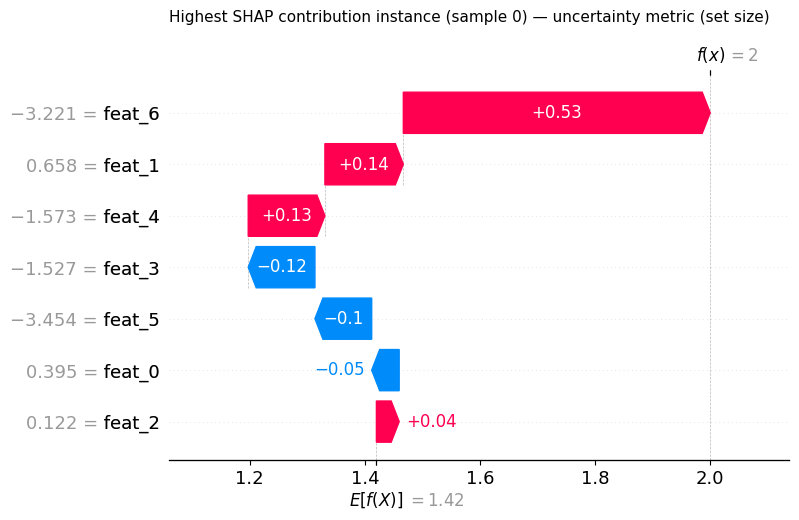

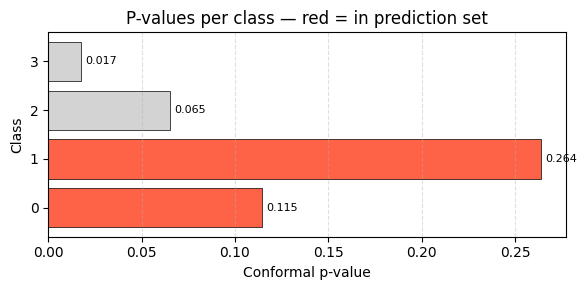

In [9]:
result = pipeline_shap.explain_uncertainty(X_test.iloc[0:1, :])

En el caso se explicación global:

ExactExplainer explainer: 101it [00:32,  2.13it/s]                         


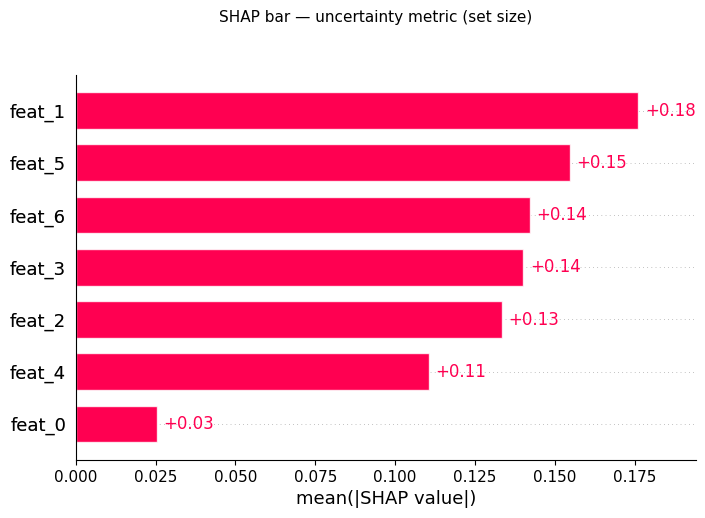

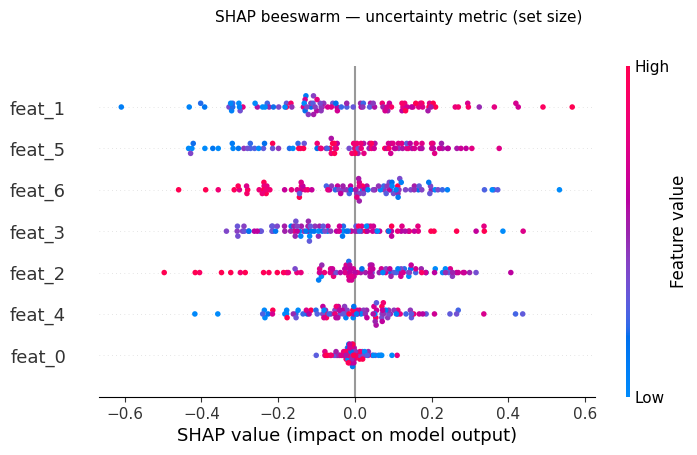

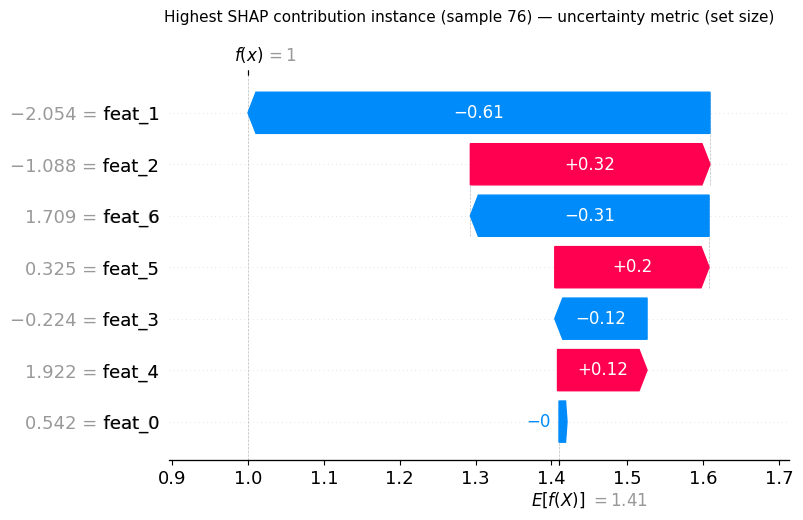

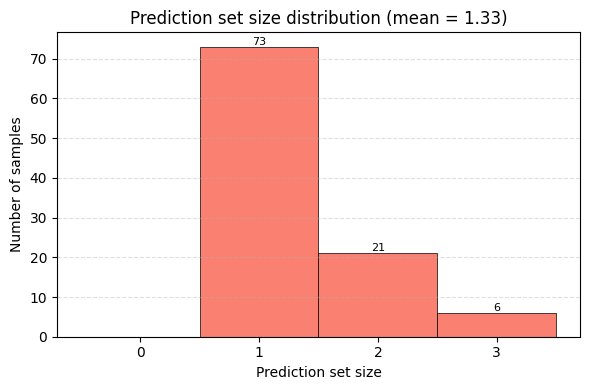

In [10]:
result = pipeline_shap.explain_uncertainty(X_test.iloc[0:100])

### 5. Resultados

El diccionario retornado contiene los intervalos de prediccion y los valores SHAP.

In [11]:
print("Keys:", list(vars(result).keys()))
print(f"\nTamaño promedio del set: {result.set_size.mean():.2f}")

# --- Métricas conformales basadas en p-valores ---
credibility = result.p_values.max(axis=1)                 # p-valor de la clase más plausible
sorted_p    = np.sort(result.p_values, axis=1)
confidence  = 1 - sorted_p[:, -2]                         # 1 − segundo p-valor más alto
print(f"\nCredibility promedio: {credibility.mean():.3f}  (qué tan plausible es la mejor clase)")
print(f"Confidence promedio:  {confidence.mean():.3f}   (qué tan separada está de la siguiente)")

# Frecuencia de aparición de cada clase en los sets 
freq = result.prediction_set.mean(axis=0)
for c, f in zip(result.classes, freq):
    print(f"  Clase {c}: aparece en {f:.1%} de los sets")

Keys: ['prediction_set', 'p_values', 'set_size', 'classes', 'explanation_values']

Tamaño promedio del set: 1.33

Credibility promedio: 0.565  (qué tan plausible es la mejor clase)
Confidence promedio:  0.920   (qué tan separada está de la siguiente)
  Clase 0: aparece en 15.0% de los sets
  Clase 1: aparece en 77.0% de los sets
  Clase 2: aparece en 27.0% de los sets
  Clase 3: aparece en 14.0% de los sets


In [12]:
# SHAP values: cada fila es una instancia, cada columna la contribucion de un feature al ancho del intervalo
print("SHAP values shape:", result.explanation_values.values.shape)
print("\nEjemplo — contribucion de cada feature para la primera instancia de test:")
for i, val in enumerate(result.explanation_values.values[0]):
    print(f"  Feature {i}: {val:+.4f}")

SHAP values shape: (100, 7)

Ejemplo — contribucion de cada feature para la primera instancia de test:
  Feature 0: -0.0478
  Feature 1: +0.1362
  Feature 2: +0.0396
  Feature 3: -0.1159
  Feature 4: +0.1332
  Feature 5: -0.0986
  Feature 6: +0.5332


## 4. Alternative explainer — PDP

`PDPUncertaintyExplainer` builds Partial Dependence Plots over the interval-width function.

**Supported kinds**: `"pdp"`, `"ice"`, `"pdp_ice"`, `"importance"` (Greenwell et al.-style importance — standard deviation of the PDP curve).

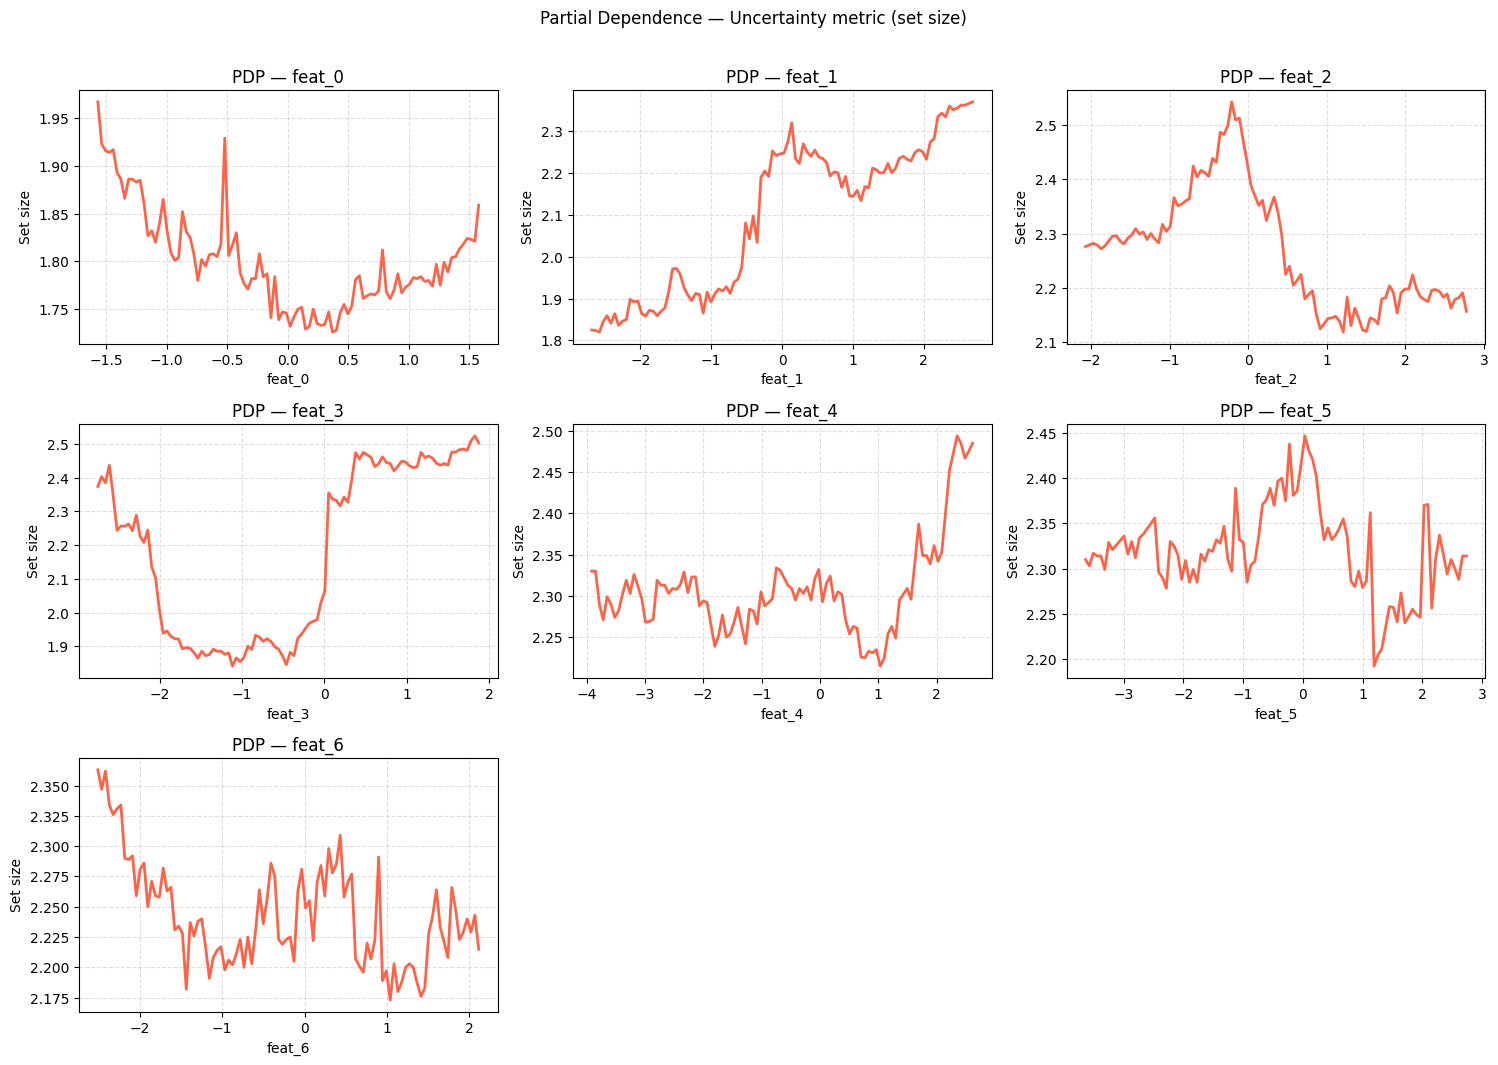

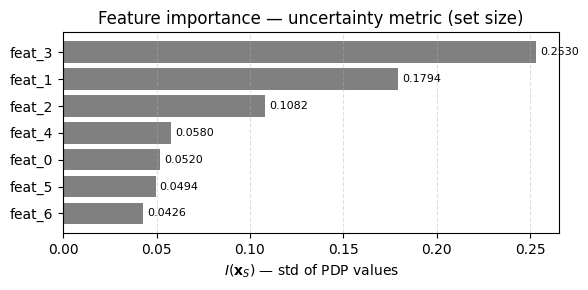

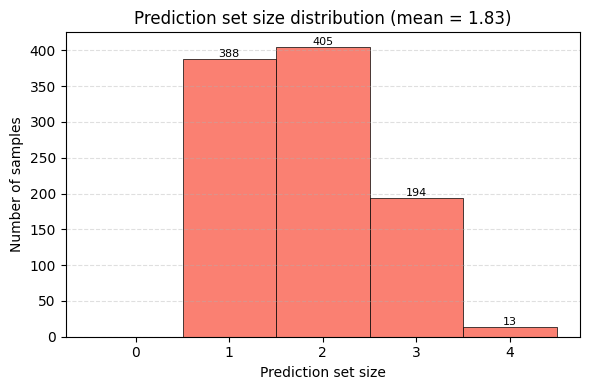

In [14]:
pipeline_pdp = UncertaintyExplanationPipeline(
    model=model,
    confidence=0.9,
    conformal_method="class_cond",
    xai_method="pdp",
)

pipeline_pdp.fit(X_train, y_train, X_calib, y_calib)
result_pdp = pipeline_pdp.explain(
    X_test,
    plot_kind=["pdp", "importance"],
    kind="average",
)

In [15]:
print("Keys:", list(vars(result_pdp).keys()))
print(f"\nTamaño promedio del set: {result_pdp.set_size.mean():.2f}")

#--- Métricas conformales basadas en p-valores ---
credibility = result_pdp.p_values.max(axis=1)                 # p-valor de la clase más plausible
sorted_p    = np.sort(result_pdp.p_values, axis=1)
confidence  = 1 - sorted_p[:, -2]                         # 1 − segundo p-valor más alto
print(f"\nCredibility promedio: {credibility.mean():.3f} ")#(qué tan plausible es la mejor clase)
print(f"Confidence promedio:  {confidence.mean():.3f} ")#(qué tan separada está de la siguiente)

Keys: ['prediction_set', 'p_values', 'set_size', 'classes', 'explanation_values']

Tamaño promedio del set: 1.83

Credibility promedio: 0.571 
Confidence promedio:  0.859 


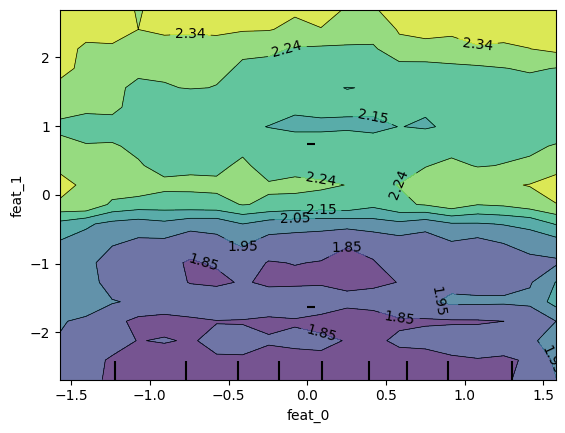

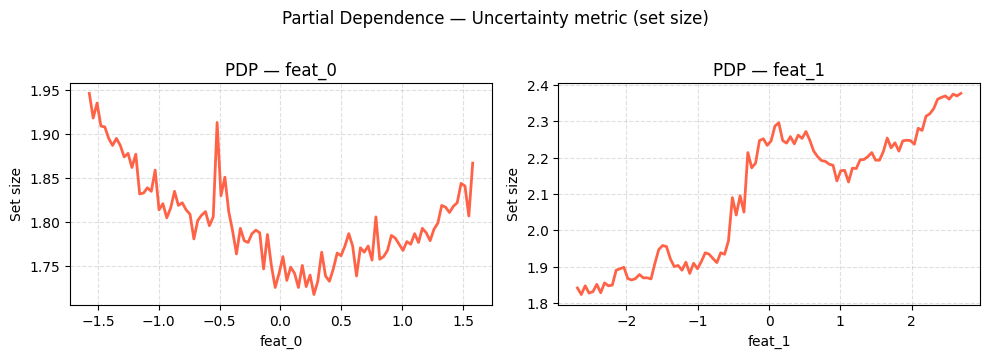

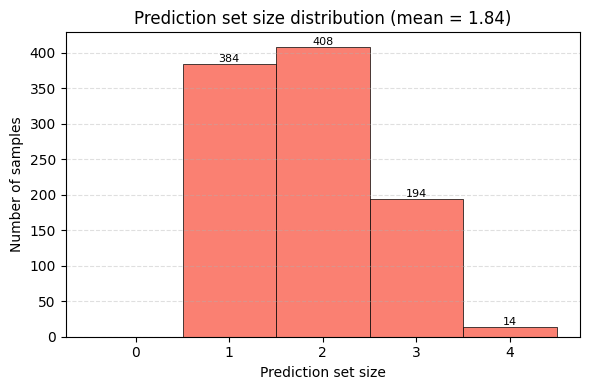

In [16]:
result = pipeline_pdp.explain_uncertainty(X_test, features = [(0, 1)])

## Explanation using LIME 

In [17]:
pipeline = UncertaintyExplanationPipeline(
    model,
    confidence=0.9,
    conformal_method="mondrian", 
    xai_method="lime",
)

In [18]:
pipeline.fit(X_train, y_train, X_calib, y_calib)

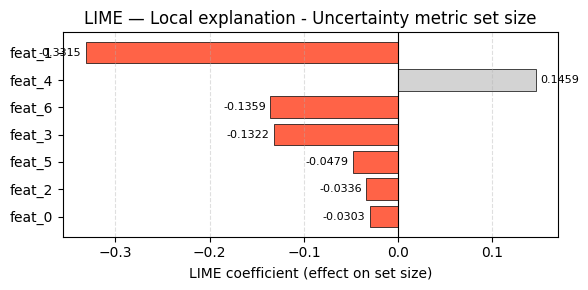

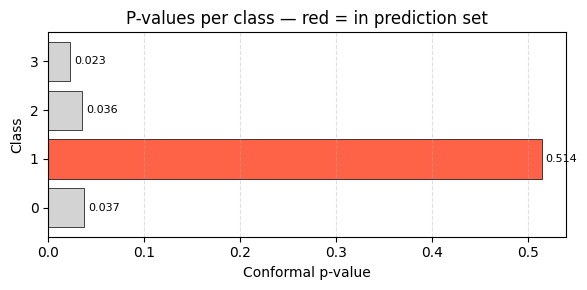

In [19]:
result = pipeline.explain_uncertainty(X_test.iloc[1:2, :])

## Varios métodos conformal

ExactExplainer explainer: 101it [00:41,  1.87it/s]                         


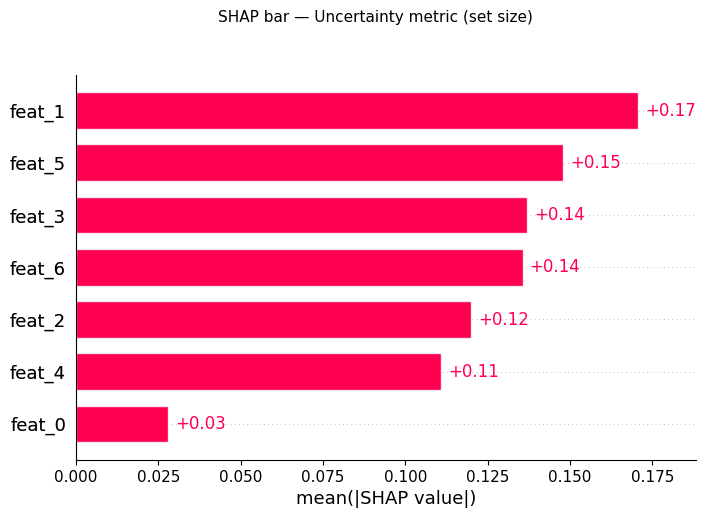

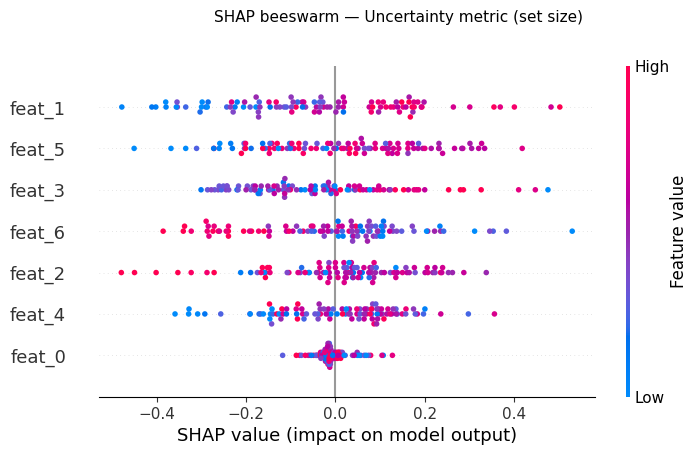

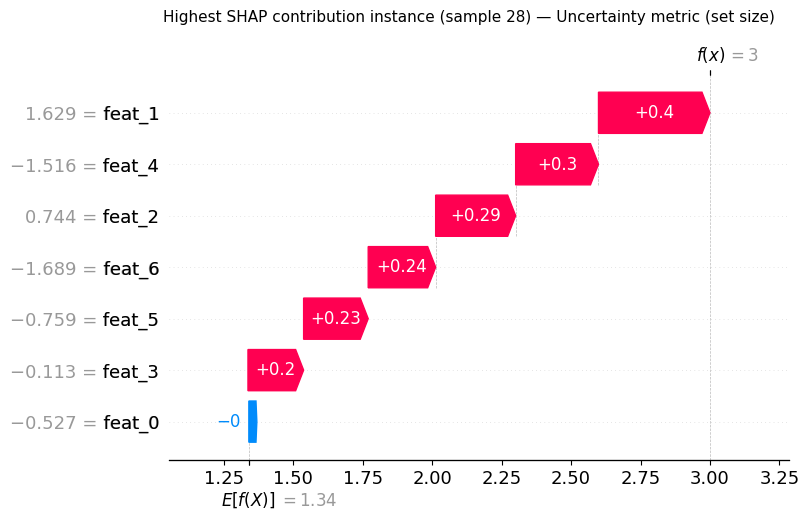

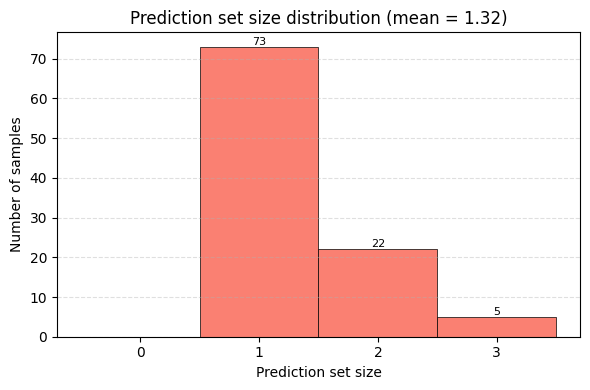

In [21]:
pipeline = UncertaintyExplanationPipeline(
    model=model,
    conformal_method="standard",
    xai_method="shap",
)
pipeline.fit(X_train, y_train, X_calib, y_calib)
result = pipeline.explain_uncertainty(X_test.iloc[0:100])

ExactExplainer explainer: 101it [00:37,  1.97it/s]                         


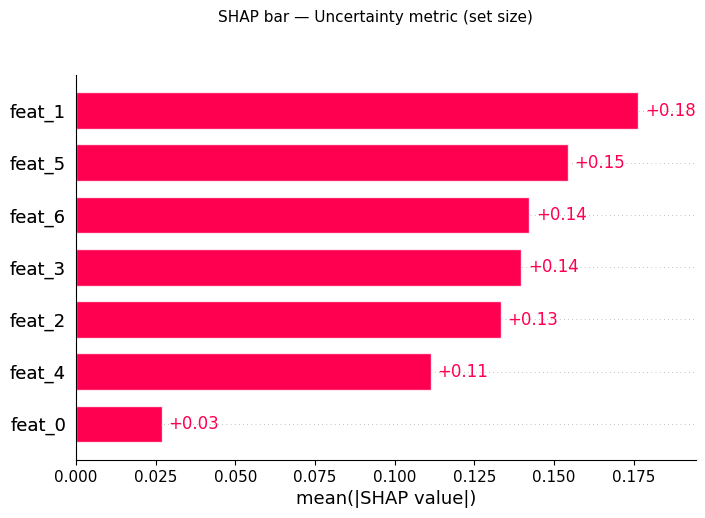

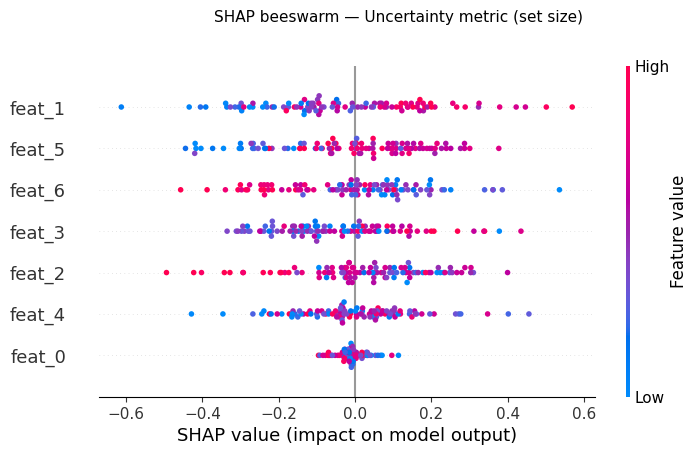

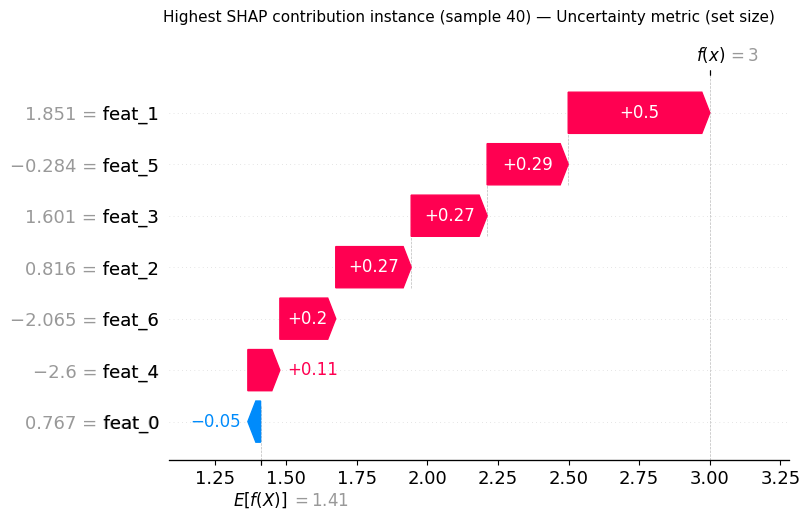

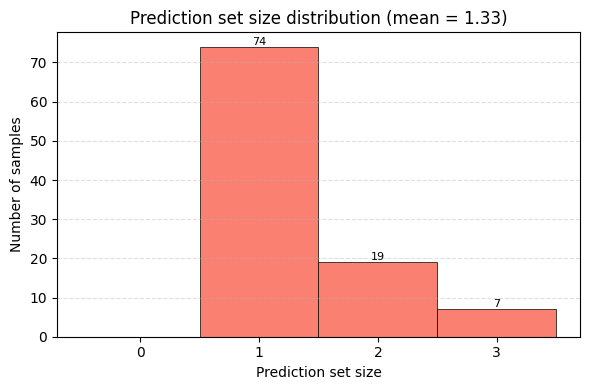

In [22]:
pipeline = UncertaintyExplanationPipeline(
    model=model,
    conformal_method="mondrian",
    xai_method="shap",
)
pipeline.fit(X_train, y_train, X_calib, y_calib)
result = pipeline.explain_uncertainty(X_test.iloc[0:100])

ExactExplainer explainer: 101it [02:18,  1.49s/it]                         


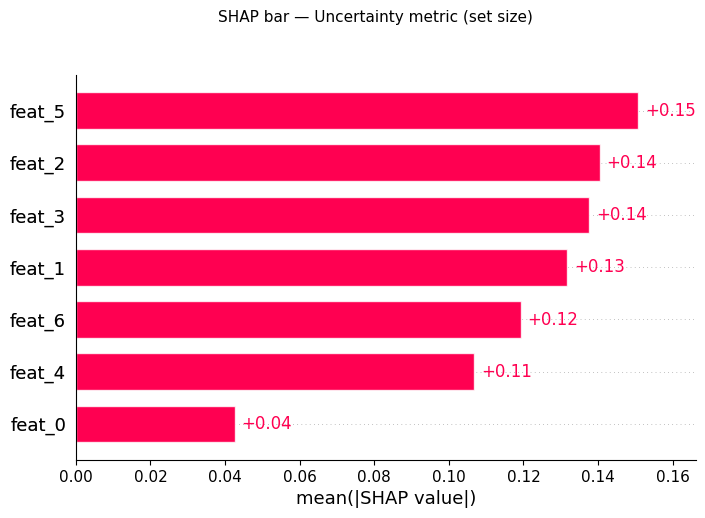

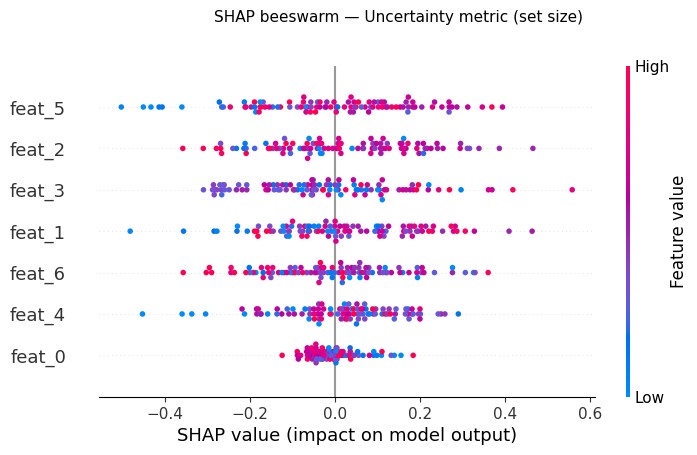

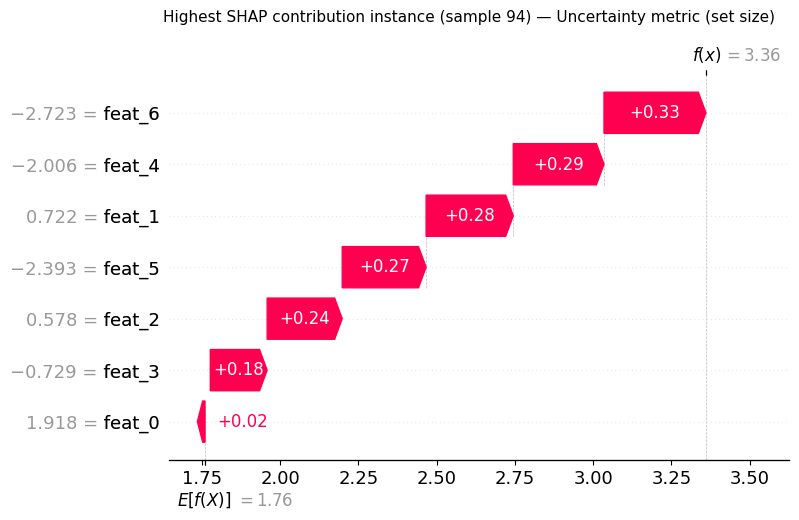

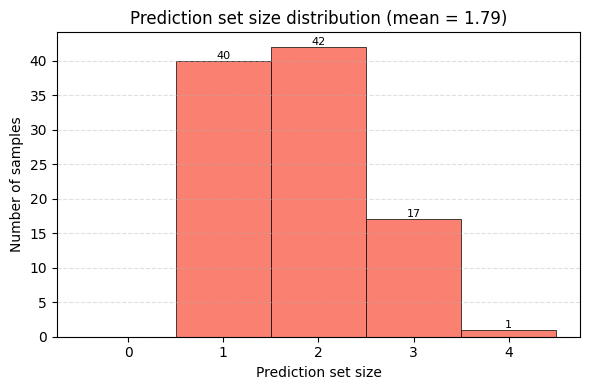

In [23]:
pipeline = UncertaintyExplanationPipeline(
    model=model,
    conformal_method="class_cond",
    xai_method="shap",
)
pipeline.fit(X_train, y_train, X_calib, y_calib)
result = pipeline.explain_uncertainty(X_test.iloc[0:100])

## Datos reales


In [ ]:
from sklearn.datasets import load_iris

X, y = load_iris(return_X_y=True)
df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

In [29]:
model = RandomForestClassifier(n_estimators=100, random_state=42, min_samples_leaf=50)

In [31]:
pipeline = UncertaintyExplanationPipeline(
    model,
    confidence=0.9,
    conformal_method="mondrian",
)

In [32]:
pipeline.fit(X_train, y_train)

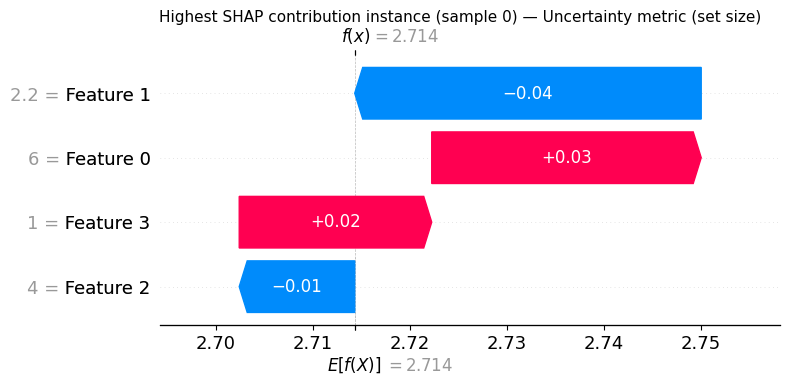

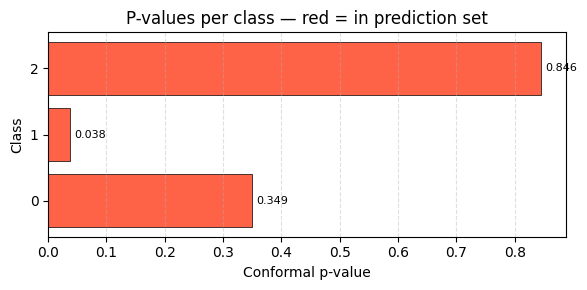

In [34]:
result = pipeline.explain_uncertainty(X_test[1:2, :])

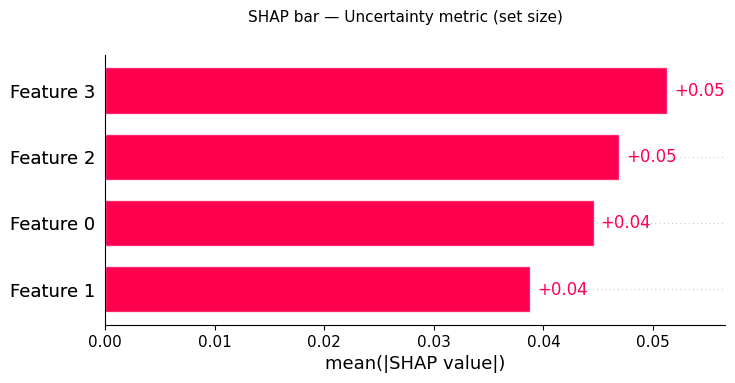

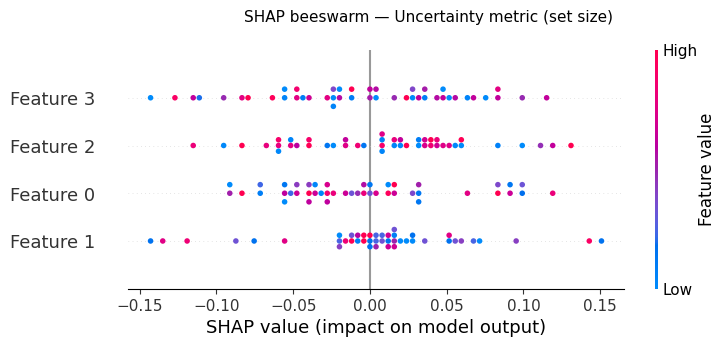

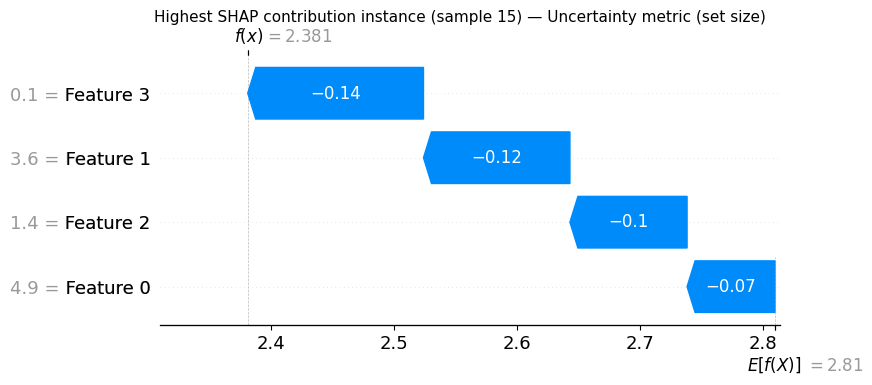

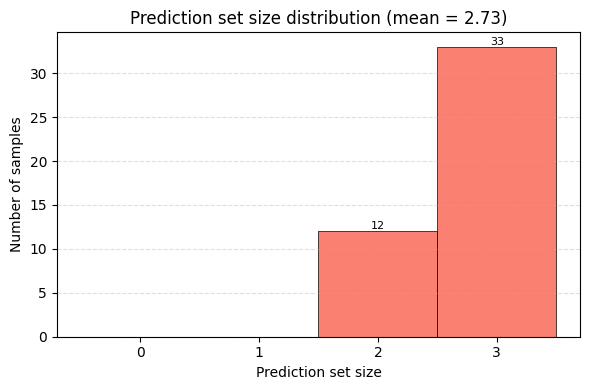

In [37]:
result = pipeline.explain_uncertainty(X_test)

In [39]:
print("Keys:", list(vars(result).keys()))
print(f"\nTamaño promedio del set: {result.set_size.mean():.2f}")

# --- Métricas conformales basadas en p-valores ---
credibility = result.p_values.max(axis=1)                 # p-valor de la clase más plausible
sorted_p    = np.sort(result.p_values, axis=1)
confidence  = 1 - sorted_p[:, -2]                         # 1 − segundo p-valor más alto
print(f"\nCredibility promedio: {credibility.mean():.3f} ")#(qué tan plausible es la mejor clase)
print(f"Confidence promedio:  {confidence.mean():.3f} ")#(qué tan separada está de la siguiente)

# Frecuencia de aparición de cada clase en los sets 
freq = result.prediction_set.mean(axis=0)
for c, f in zip(result.classes, freq):
    print(f"  Clase {c}: aparece en {f:.1%} de los sets")

Keys: ['prediction_set', 'p_values', 'set_size', 'classes', 'explanation_values']

Tamaño promedio del set: 2.73

Credibility promedio: 0.786 
Confidence promedio:  0.518 
  Clase 0: aparece en 100.0% de los sets
  Clase 1: aparece en 73.3% de los sets
  Clase 2: aparece en 100.0% de los sets


In [41]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

### LIME

In [43]:
pipeline = UncertaintyExplanationPipeline(
    model,
    confidence=0.9,
    conformal_method="mondrian",
    xai_method="lime"
)
pipeline.fit(X_train, y_train)

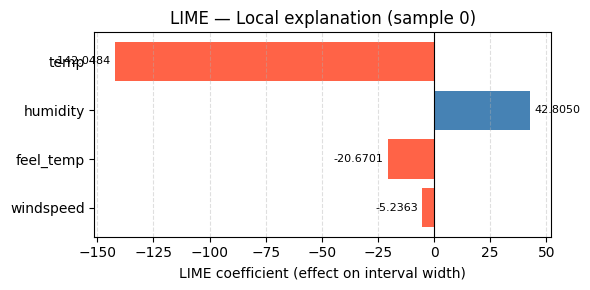

In [24]:
result = pipeline.explain_uncertainty(X_test.iloc[1:2, :])

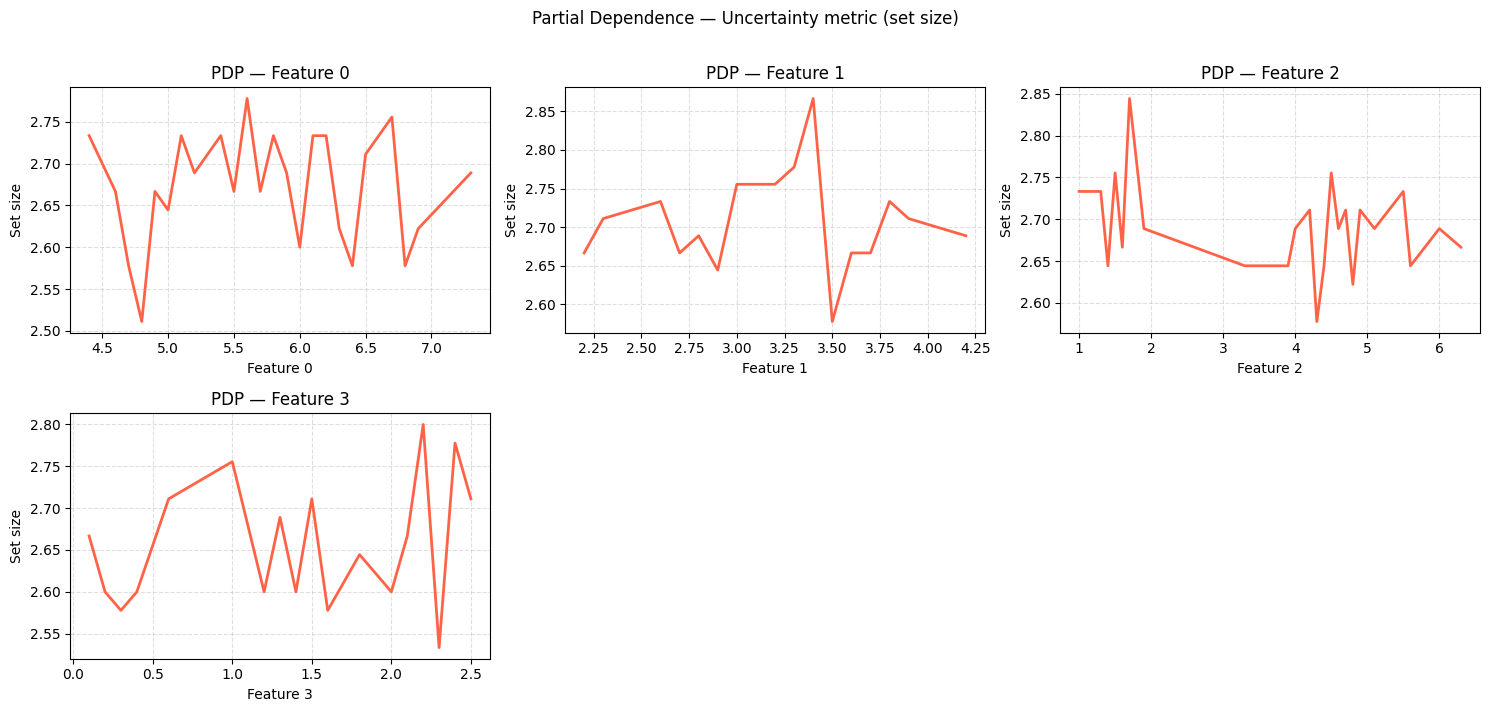

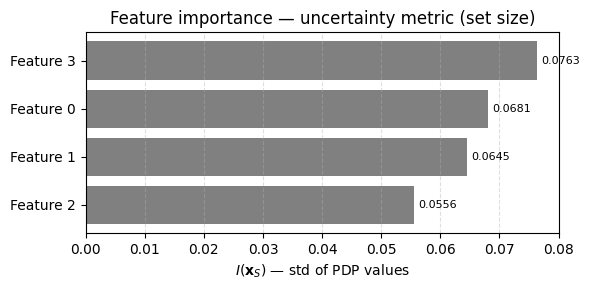

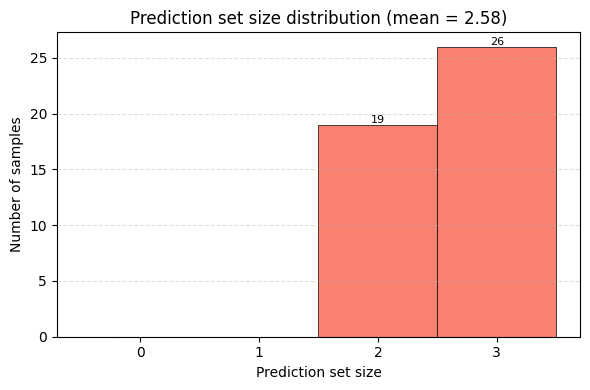

In [45]:
pipeline = UncertaintyExplanationPipeline(
    model,
    confidence=0.9,
    conformal_method="mondrian",
    xai_method="pdp"
)
pipeline.fit(X_train, y_train)
result = pipeline.explain_uncertainty(X_test, plot_kind=["pdp", "importance"])